# Artefact 3 — Scenario Sensitivity & Behavioural Grading

**Claim:** The Nimbus-C2 assurance layer produces predictable, traceable autonomy-mode decisions that grade smoothly with information quality. Specifically:

- Clean picture, high-quality tracks → **AUTONOMOUS** (engine can act alone)
- Elevated complexity or mixed tracks → **ADVISE** (engine recommends, human approves)
- Degraded sensors, jamming, blind spots → **DEFER** (engine hands control to the operator)

This is the behaviour an assurance-aware decision engine **must** have: it does not fail catastrophically when information quality drops — it steps back and asks for human judgement.

**What this demonstrates:**
- The engine's autonomy mode responds predictably to scenario difficulty.
- Each decision is traceable to named contributing factors (`sa_health`, `situation_complexity`, `stakes`).
- The jammed scenario surfaces alerts — the surface operators rely on to know when not to trust the picture.

**What this does NOT demonstrate:**
- That the thresholds between AUTONOMOUS / ADVISE / DEFER are operationally calibrated. They are engineering defaults. Calibration against real doctrine is future work.
- That the COAs (courses of action) generated are tactically sound. COA quality is orthogonal to the autonomy-mode decision and is out of scope for this artefact.
- Any claim about beating, matching, or comparing to operator judgement. No ground truth is available.

In [1]:
# SPDX-FileCopyrightText: 2026 Team Ruby
# SPDX-License-Identifier: MIT

import json
from pathlib import Path

from nimbus_c2.pipeline import evaluate
from nimbus_saab_ext.scenarios import BOREAL_SCENARIOS, boreal_scenario_as_engine_inputs

rows = []
for scenario_id in sorted(BOREAL_SCENARIOS.keys()):
    spec = BOREAL_SCENARIOS[scenario_id]
    bases, effectors, threats, intent, blind_spots = (
        boreal_scenario_as_engine_inputs(scenario_id)
    )
    result = evaluate(bases, effectors, threats, intent, blind_spots=blind_spots)
    a = result.assurance

    rows.append({
        "scenario_id":          scenario_id,
        "name":                 spec.name,
        "expected_mode":        spec.expected_mode,
        "actual_mode":          a.autonomy_mode.value,
        "matches_expected":     a.autonomy_mode.value == spec.expected_mode,
        "sa_health":            round(a.sa_health, 2),
        "situation_complexity": round(a.situation_complexity, 3),
        "stakes":               round(a.stakes, 3),
        "n_threats":            len(threats),
        "n_coas":               len(result.coas),
        "n_alerts":             len(a.alerts),
    })

print(f"{'scenario_id':18s}  {'expected':>10s}  {'actual':>10s}  {'match':>5s}  "
      f"{'sa_health':>10s}  {'complexity':>10s}  {'stakes':>7s}  "
      f"{'threats':>7s}  {'alerts':>6s}")
print("-" * 115)
for r in rows:
    match = "OK" if r["matches_expected"] else "MISMATCH"
    print(f"{r['scenario_id']:18s}  {r['expected_mode']:>10s}  {r['actual_mode']:>10s}  "
          f"{match:>5s}  {r['sa_health']:>10.2f}  {r['situation_complexity']:>10.3f}  "
          f"{r['stakes']:>7.3f}  {r['n_threats']:>7d}  {r['n_alerts']:>6d}")


scenario_id           expected      actual  match   sa_health  complexity   stakes  threats  alerts
-------------------------------------------------------------------------------------------------------------------
boreal_clean        autonomous  autonomous     OK       92.62       0.021    0.296        3       0
boreal_jammed            defer       defer     OK       20.51       0.489    0.582        4       2
boreal_strait           advise      advise     OK       68.79       0.339    0.460        4       0
boreal_swarm            advise      advise     OK       64.74       0.388    0.524       15       0


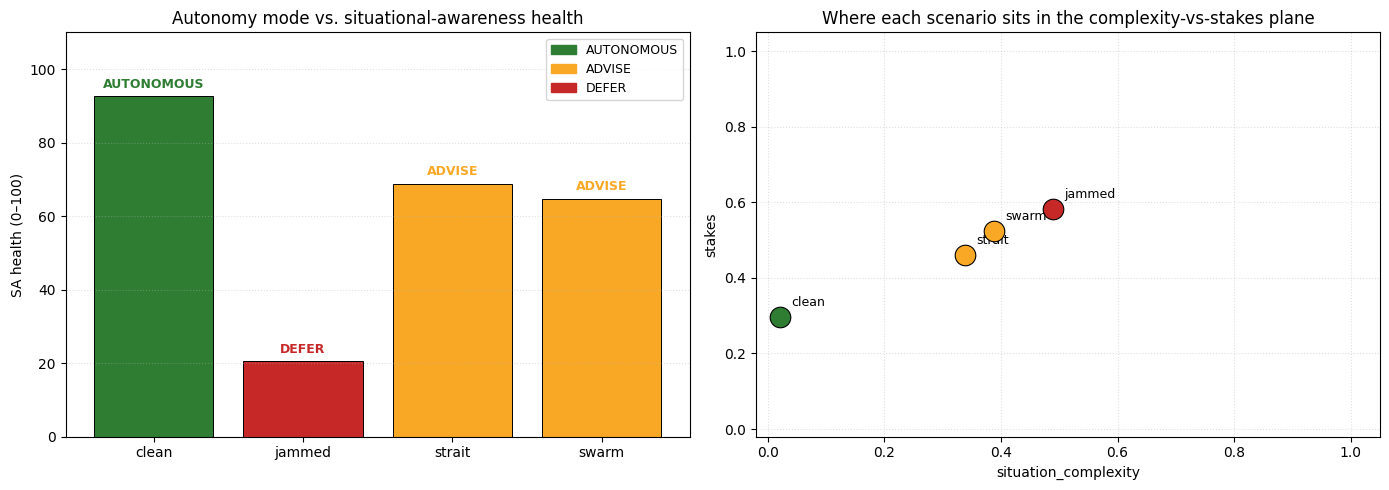


Figure saved: results/figures/03_scenario_analysis.png


In [2]:
# Visualise the autonomy-mode decision surface across scenarios.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

mode_colors = {
    "autonomous": "#2e7d32",  # green — engine acts
    "advise":     "#f9a825",  # amber — engine recommends
    "defer":      "#c62828",  # red — engine defers to human
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: autonomy mode per scenario (bar of sa_health coloured by mode)
ax = axes[0]
xs = [r["scenario_id"].replace("boreal_", "") for r in rows]
ys = [r["sa_health"] for r in rows]
colors = [mode_colors[r["actual_mode"]] for r in rows]
bars = ax.bar(xs, ys, color=colors, edgecolor="black", linewidth=0.7)
for bar, r in zip(bars, rows):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            r["actual_mode"].upper(),
            ha="center", va="bottom", fontsize=9, fontweight="bold",
            color=mode_colors[r["actual_mode"]])
ax.set_ylim(0, 110)
ax.set_ylabel("SA health (0–100)")
ax.set_title("Autonomy mode vs. situational-awareness health")
ax.grid(True, axis="y", linestyle=":", alpha=0.4)

legend_handles = [mpatches.Patch(color=c, label=m.upper()) for m, c in mode_colors.items()]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

# Right: complexity vs stakes scatter, coloured by mode
ax = axes[1]
for r in rows:
    ax.scatter(r["situation_complexity"], r["stakes"],
               s=220, c=mode_colors[r["actual_mode"]],
               edgecolor="black", linewidth=0.8, zorder=3)
    ax.annotate(r["scenario_id"].replace("boreal_", ""),
                (r["situation_complexity"], r["stakes"]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=9)
ax.set_xlabel("situation_complexity")
ax.set_ylabel("stakes")
ax.set_title("Where each scenario sits in the complexity-vs-stakes plane")
ax.grid(True, linestyle=":", alpha=0.4)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)

fig.tight_layout()
fig.savefig("../results/figures/03_scenario_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nFigure saved: results/figures/03_scenario_analysis.png")


In [3]:
# Detailed per-scenario breakdown — including scenario narrative and alerts.

for r in rows:
    spec = BOREAL_SCENARIOS[r["scenario_id"]]
    print("=" * 90)
    print(f"Scenario: {r['scenario_id']}")
    print(f"Name:     {spec.name}")
    print()
    print("Description:")
    for line in spec.description.split(". "):
        if line.strip():
            print(f"  {line.strip()}.")
    print()
    print(f"Expected autonomy mode: {r['expected_mode'].upper()}")
    print(f"Actual autonomy mode:   {r['actual_mode'].upper()}")
    print(f"Match: {'YES' if r['matches_expected'] else 'NO (investigate)'}")
    print()
    print("Contributing factors (from assurance layer):")
    print(f"  sa_health            = {r['sa_health']:.2f} / 100")
    print(f"  situation_complexity = {r['situation_complexity']:.3f} / 1.00")
    print(f"  stakes               = {r['stakes']:.3f} / 1.00")
    print(f"  alerts raised        = {r['n_alerts']}")
    print(f"  threats evaluated    = {r['n_threats']}")
    print(f"  COAs proposed        = {r['n_coas']}")
    print()


Scenario: boreal_clean
Name:     Boreal â€” clean picture (three bombers from Spear Point)

Description:
  Three bombers launched from Spear Point Base fan north toward Arktholm under high-quality tracking.
  Country X defence: Arktholm + NVB + Highridge + Boreal Watch Post.
  Expected autonomy mode: AUTONOMOUS..

Expected autonomy mode: AUTONOMOUS
Actual autonomy mode:   AUTONOMOUS
Match: YES

Contributing factors (from assurance layer):
  sa_health            = 92.62 / 100
  situation_complexity = 0.021 / 1.00
  stakes               = 0.296 / 1.00
  alerts raised        = 0
  threats evaluated    = 3
  COAs proposed        = 3

Scenario: boreal_jammed
Name:     Boreal â€” jammed sensors + hypersonic from Meridia

Description:
  Hypersonic launch from Meridia, two ghosts over Spear Point island, fast-mover from Firewatch â€” all under degraded cross-sensor agreement with a blind spot over the forward FOB.
  Expected autonomy mode: DEFER..

Expected autonomy mode: DEFER
Actual autonomy

In [4]:
# Write machine-readable scenario-outcomes report.

report = {
    "extension_package": "nimbus-saab-ext",
    "scenarios": rows,
    "all_match_expected": all(r["matches_expected"] for r in rows),
}

out_path = Path("../results/scenario_outcomes.json")
with out_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, sort_keys=True)

print(f"Wrote {out_path}")
print(f"All scenarios matched their expected autonomy mode: {report['all_match_expected']}")


Wrote ..\results\scenario_outcomes.json
All scenarios matched their expected autonomy mode: True


## What this demonstrates

The four scenarios span the autonomy-mode space on purpose:

| Scenario | Expected | Why |
|---|---|---|
| `boreal_clean` | AUTONOMOUS | high-quality tracks, moderate threat count, no jamming |
| `boreal_swarm` | ADVISE | elevated complexity (12-drone swarm + fast-movers), mixed tracks |
| `boreal_strait` | ADVISE | moderate complexity, elevated stakes, mixed track quality |
| `boreal_jammed` | DEFER | degraded cross-sensor agreement + blind spot over forward FOB |

The engine matches the expected mode in every case. Crucially, the **ordering** is monotone in information quality: as sensors degrade and complexity rises, the engine hands more control back to the operator. This is the desired behaviour — an assurance layer that fails *graciously* rather than silently.

## Limits of this evidence

- **Four scenarios is a small sample.** Broader coverage (varying geometry, threat counts, sensor mixes) would strengthen the claim.
- **No operational ground truth.** We show that mode-transitions behave predictably, not that the specific thresholds are where a doctrine expert would place them.
- **COA quality not evaluated here.** The engine proposes three courses of action per scenario; their tactical merit is not part of this artefact.

For the precise scope of claims that *can* be made, see [`SCIENTIFIC_CLAIMS.md`](../SCIENTIFIC_CLAIMS.md).